In [2]:

#Preparação dados para modelo
#matrizes de distâncias, vetores de demandas
import math

def distancia_euclidiana(x1, y1, x2, y2):
    return math.sqrt((x2 - x1)**2 + (y2 - y1)**2)

def matriz_distancia_clientes(clientes):

    nomes = list(clientes.keys())
    num_clientes = len(nomes)
    lista_duracao = []
    matriz = [[0.0]*num_clientes for _ in range(num_clientes)]
    for i in range(num_clientes):
        lista_duracao.append(clientes[nomes[i]]['duracao_estimada_minutos'])
        for j in range(num_clientes):
            if i == j:
                matriz[i][j] = 0.0
            else:
                d = distancia_euclidiana(clientes[nomes[i]]['endereco_x'], clientes[nomes[i]]['endereco_y'],
                                         clientes[nomes[j]]['endereco_x'], clientes[nomes[j]]['endereco_y'])
                matriz[i][j] = d

    return matriz, num_clientes, lista_duracao

def matriz_distancia_tecnico_cliente(tecnicos, clientes):
    nomes_tec = list(tecnicos.keys())
    nomes_cli = list(clientes.keys())
    num_tecnicos = len(nomes_tec)


    matriz = [[0.0] * len(nomes_cli) for _ in range(len(nomes_tec))]

    for i, tec in enumerate(nomes_tec):
        for j, cli in enumerate(nomes_cli):
            matriz[i][j] = distancia_euclidiana(
                tecnicos[tec]['endereco_x'], tecnicos[tec]['endereco_y'],
                clientes[cli]['endereco_x'], clientes[cli]['endereco_y']
            )

    return matriz, num_tecnicos

import numpy as np

def juntar_matrizes_tempo(dij, aij):
    num_tec = len(aij)
    num_cli = len(dij)
    total = num_tec + num_cli

    matriz = [[0.0] * total for _ in range(total)]

    for i in range(num_cli):
        for j in range(num_cli):
            matriz[num_tec + i][num_tec + j] = dij[i][j]

    for i in range(num_tec):
        for j in range(num_cli):
            matriz[i][num_tec + j] = aij[i][j]
            matriz[num_tec + j][i] = aij[i][j]

    matriz_np = np.array(matriz)
    matriz_tempo_np = (matriz_np / 20) * 60
    matriz_tempo = matriz_tempo_np.tolist()
    with open("matriz_tempo.csv", "w") as f:
      for linha in matriz_tempo:
          f.write(" ".join(str(val) for val in linha) + "\n")

    return matriz_tempo




In [ ]:
pip install gurobipy

In [ ]:
# modelo matemático
def solve_MILP(num_tecnicos, num_clientes, num_dias, matriz_tempo, lista_duracao):
  import gurobipy as gp
  from gurobipy import GRB


  K = range(num_tecnicos)          #técnicos
  C = range(num_clientes)          # clientes
  T = range(num_dias)              # dias

  L= 480 #minutos por rota (max)

  nos = range(num_clientes + num_tecnicos)
  nos_tecnicos= range(num_tecnicos) # identifica a origem de cada técnico
  nos_clientes= range(num_tecnicos, num_tecnicos + num_clientes)

  m = gp.Model("Harumi")

  x=m.addVars(nos, nos, K, T, vtype=GRB.BINARY, name="x")
  u = m.addVars(nos_clientes, K, T, vtype=GRB.CONTINUOUS, lb=1, ub=num_clientes, name="u")

  #Definindo varáveis zeradas   i,j in nos_tecnicos
  #i=i
  for i in nos:
    for k in K:
        for t in T:
          x[i, i, k, t].ub = 0
  #i,j in nos_tecnicos
  for i in nos_tecnicos:
    for j in nos_tecnicos:
        if i != j:
            for k in K:
                for t in T:
                    x[i, j, k, t].ub = 0
  #técnico não pode sair de um depósito que não é seu
  for k in K:
    for i in nos_tecnicos:
        if i != k:
            for j in nos:
                for t in T:
                    x[i, j, k, t].ub = 0
  #técnico não pode entrar em um depósito que não é seu
  for k in K:
    for j in nos_tecnicos:
        if j != k:
            for i in nos:
                for t in T:
                    x[i, j, k, t].ub = 0

  m.setObjective(gp.quicksum(matriz_tempo[i][j] * x[i, j, k, t] for i in nos for j in nos for k in K for t in T), GRB.MINIMIZE)

  r1=m.addConstrs(gp.quicksum(x[i, j, k, t] for j in nos for t in T for k in K) == 1 for i in nos_clientes)
  #todo cliente deve ser visitado uma única vez no período T por um técnico
  r2=m.addConstrs(gp.quicksum(x[k, j, k, t] for j in nos)<=1 for k in K for t in T)
  #cada técnico deve sair uma única vez por dia da sua origem
  r3=m.addConstrs(gp.quicksum(x[i, k, k, t] for i in nos)<=1 for k in K for t in T)
  #cada técnico deve retornar uma única vez por dia para sua origem
  r4=m.addConstrs(gp.quicksum(x[i, j, k, t] for j in nos)==gp.quicksum(x[j, i, k, t] for j in nos) for i in nos_clientes for k in K for t in T)
  #conservação de fluxo para os nós clientes
  r5=m.addConstrs(gp.quicksum(x[i, j, k, t]*matriz_tempo[i][j] for i in nos for j in nos) +
                  gp.quicksum(lista_duracao[i-num_tecnicos]*(gp.quicksum(x[i,j,k,t] for j in nos)) for i in nos_clientes) <= L for k in K for t in T)
  #limite de tempo por rota
  r6=m.addConstrs(u[i,k,t] - u[j,k,t] + (num_clientes+1)*x[i, j, k, t] <= num_clientes for i in nos_clientes for j in nos_clientes for k in K for t in T if i!=j)
  #elimina sub-rotas


  m.write("Harumi.lp")
  print("Arquivo lp gerado")

''' # usar para otimizar
  m.optimize()
  print("Otimização concluída")
  if m.Status == GRB.INFEASIBLE:
      print("Modelo é infactível. Calculando IIS...")
      m.computeIIS()

      m.write("modelo_iis.ilp")
      print("IIS salvo em 'modelo_iis.ilp'. Analise o arquivo para identificar restrições conflitantes.")

      print("\nRestrições que compõem o IIS:")
      for c in m.getConstrs():
          if c.IISConstr:
              print(f" - {c.ConstrName}")

      for v in m.getVars():
          if v.IISLB:
              print(f" - Limite inferior da variável '{v.VarName}'")
          if v.IISUB:
              print(f" - Limite superior da variável '{v.VarName}'")
  else:
      print("Modelo é factível.")


  if m.status == GRB.OPTIMAL:
      with open("solucao.txt", "w") as f:
          for i in nos:
              for j in nos:
                  for k in K:
                      for t in T:
                          if x[i, j, k, t].X > 0.5:
                              f.write(f"x[{i},{j},{k},{t}] = 1\n")
      print("Solução salva'")
'''



' # usar para otimizar\n  m.optimize()\n  print("Otimização concluída")\n  if m.Status == GRB.INFEASIBLE:\n      print("Modelo é infactível. Calculando IIS...")\n      m.computeIIS()\n\n      m.write("modelo_iis.ilp")\n      print("IIS salvo em \'modelo_iis.ilp\'. Analise o arquivo para identificar restrições conflitantes.")\n\n      print("\nRestrições que compõem o IIS:")\n      for c in m.getConstrs():\n          if c.IISConstr:\n              print(f" - {c.ConstrName}")\n\n      for v in m.getVars():\n          if v.IISLB:\n              print(f" - Limite inferior da variável \'{v.VarName}\'")\n          if v.IISUB:\n              print(f" - Limite superior da variável \'{v.VarName}\'")\n  else:\n      print("Modelo é factível.")\n\n\n  if m.status == GRB.OPTIMAL:\n      with open("solucao.txt", "w") as f:\n          for i in nos:\n              for j in nos:\n                  for k in K:\n                      for t in T:\n                          if x[i, j, k, t].X > 0.5:\n    

In [47]:
def salvar_resultados(solucao, tecnicos, clientes, num_dias):
    with open("resultados_simples.txt", 'w') as f:
        for dia in range(num_dias):
            f.write(f"\nDIA {dia}:\n")
            for k, nome_tecnico in enumerate(tecnicos.keys()):
                rotas = solucao.get(dia, {}).get(k, [])
                for rota in rotas:
                    if rota:
                        nomes = [list(clientes.keys())[c] for c in rota]
                        f.write(f"  {nome_tecnico}: {nomes} (índices {rota})\n")
    print("Resultado salvo em 'resultados_simples.txt'")

def plotar_rotas(solucao, tecnicos, clientes, num_dias, nome_arquivo="rotas.png"):
    """
    solucao: dict[dia][tecnico] = lista de rotas (cada rota = lista de ids de clientes)
    tecnicos: dict {nome: {'endereco_x': float, 'endereco_y': float}}
    clientes: dict {nome: {'endereco_x': float, 'endereco_y': float, ...}}
    num_dias: total de dias
    """
    # Mapeamento: índice do cliente (0..num_clientes-1) -> coordenadas
    lista_clientes = list(clientes.values())
    coords_clientes = [(c['endereco_x'], c['endereco_y']) for c in lista_clientes]

    # Mapeamento: índice do técnico (0..num_tecnicos-1) -> coordenadas
    lista_tecnicos = list(tecnicos.values())
    coords_tecnicos = [(t['endereco_x'], t['endereco_y']) for t in lista_tecnicos]

    # Cores para diferenciar os técnicos (ou use um colormap)
    cores_tecnicos = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'olive', 'cyan']

    plt.figure(figsize=(12, 10))

    # Primeiro, plota todos os pontos fixos (opcional, pode pular se já tiver)
    # Técnicos (depósitos)
    for i, (x, y) in enumerate(coords_tecnicos):
        plt.scatter(x, y, c='red', marker='s', s=120, edgecolors='black', zorder=5)
        plt.text(x, y, f'T{i}', fontsize=9, ha='right', va='bottom')

    # Clientes
    for i, (x, y) in enumerate(coords_clientes):
        plt.scatter(x, y, c='green', marker='o', s=60, edgecolors='black', zorder=3)
        plt.text(x, y, f'C{i}', fontsize=8, ha='center', va='top')

    # Para cada dia e técnico, desenha as rotas
    for dia in range(num_dias):
        for k in range(len(tecnicos)):  # k = índice do técnico
            rotas_do_tecnico = solucao.get(dia, {}).get(k, [])
            if not rotas_do_tecnico:
                continue

            cor = cores_tecnicos[k % len(cores_tecnicos)]
            estilo_linha = '-' if dia == 0 else '--'  # diferente traço para cada dia (opcional)

            # Desenha cada rota
            for rota in rotas_do_tecnico:
                if not rota:
                    continue
                # Coordenadas do depósito (técnico k)
                x_dep, y_dep = coords_tecnicos[k]
                # Percorre a rota: depósito -> clientes -> depósito
                pontos_x = [x_dep]
                pontos_y = [y_dep]
                for cliente_idx in rota:
                    xc, yc = coords_clientes[cliente_idx]
                    pontos_x.append(xc)
                    pontos_y.append(yc)
                pontos_x.append(x_dep)
                pontos_y.append(y_dep)

                plt.plot(pontos_x, pontos_y, color=cor, linestyle=estilo_linha,
                         linewidth=2, marker='o', markersize=4,
                         label=f'D{dia} T{k}' if len(plt.gca().get_legend_handles_labels()[1]) < 20 else "")

    # Ajustes finais
    plt.title('Rotas geradas pela heurística', fontsize=14)
    plt.xlabel('Coordenada X')
    plt.ylabel('Coordenada Y')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='best', fontsize=8, ncol=3)
    plt.tight_layout()
    plt.savefig(nome_arquivo, dpi=150)


In [48]:
# Heurística Clarke & Wright – num_dias calculado automaticamente
import itertools
import numpy as np
import random
from typing import List, Dict, Tuple

class ClarkeWrightSolver:
    def __init__(self, num_tecnicos: int, num_clientes: int,
                 matriz_tempo: List[List[float]], duracao_servico: List[float],
                 tempo_max_rota: float, num_dias: int = None):

        self.num_tecnicos = num_tecnicos
        self.num_clientes = num_clientes
        self.num_dias = num_dias
        self.matriz_tempo = matriz_tempo
        self.duracao_servico = duracao_servico
        self.tempo_max_rota = tempo_max_rota
        self.idx_clientes = list(range(num_tecnicos, num_tecnicos + num_clientes))

    def _calculasavings(self, i: int, j: int, k: int) -> float:
        i_global = self.idx_clientes[i]
        j_global = self.idx_clientes[j]
        k_global = k
        return (self.matriz_tempo[k_global][i_global] +
                self.matriz_tempo[k_global][j_global] -
                self.matriz_tempo[i_global][j_global])

    def _tempo_rota(self, rota: List[int], k: int) -> float:
        if not rota:
            return 0.0
        k_global = k
        servico_total = sum(self.duracao_servico[c] for c in rota)
        tempo_viagem = 0.0
        primeiro = self.idx_clientes[rota[0]]
        tempo_viagem += self.matriz_tempo[k_global][primeiro]
        for idx in range(len(rota) - 1):
            a = self.idx_clientes[rota[idx]]
            b = self.idx_clientes[rota[idx + 1]]
            tempo_viagem += self.matriz_tempo[a][b]
        ultimo = self.idx_clientes[rota[-1]]
        tempo_viagem += self.matriz_tempo[ultimo][k_global]
        return tempo_viagem + servico_total

    def _tempo_rota_apos_merge(self, rota_a: List[int], rota_b: List[int],
                               a: int, b: int, k: int) -> float:
        if rota_a[-1] != a:
            rota_a = rota_a[::-1]
        if rota_b[0] != b:
            rota_b = rota_b[::-1]
        nova_rota = rota_a + rota_b
        return self._tempo_rota(nova_rota, k)

    def _atribuicao_inicial(self) -> Dict[int, Dict[int, List[List[int]]]]:
        dist_tecnico_cliente = []
        for c in range(self.num_clientes):
            c_global = self.idx_clientes[c]
            dists = [self.matriz_tempo[k][c_global] for k in range(self.num_tecnicos)]
            dist_tecnico_cliente.append(dists)

        dias_provisorios = 1
        solucao = {dia: {k: [] for k in range(self.num_tecnicos)} for dia in range(dias_provisorios)}
        for cliente in range(self.num_clientes):
            tecnico = np.argmin(dist_tecnico_cliente[cliente])
            solucao[0][tecnico].append([cliente])
        return solucao

    def _aplicar_clarke_wright_(self, solucao_inicial):
        rotas_por_tecnico = {k: [] for k in range(self.num_tecnicos)}
        for dia in range(len(solucao_inicial)):
            for k in range(self.num_tecnicos):
                rotas_por_tecnico[k].extend(solucao_inicial[dia][k])

        for k, rotas in rotas_por_tecnico.items():
            if len(rotas) <= 1:
                continue

            rota_do_cliente = {}
            for idx, rota in enumerate(rotas):
                for cliente in rota:
                    rota_do_cliente[cliente] = idx

            clientes_do_tecnico = list(rota_do_cliente.keys())
            pares = []
            for i in range(len(clientes_do_tecnico)):
                for j in range(i+1, len(clientes_do_tecnico)):
                    ci = clientes_do_tecnico[i]
                    cj = clientes_do_tecnico[j]
                    saving = self._calculasavings(ci, cj, k)
                    if saving > 0:
                        pares.append((saving, ci, cj))
            pares.sort(reverse=True, key=lambda x: x[0])

            for saving, i, j in pares:
                if rota_do_cliente.get(i) is None or rota_do_cliente.get(j) is None:
                    continue
                idx_i = rota_do_cliente[i]
                idx_j = rota_do_cliente[j]
                if idx_i == idx_j:
                    continue
                rota_i = rotas[idx_i]
                rota_j = rotas[idx_j]
                if (rota_i[0] != i and rota_i[-1] != i) or (rota_j[0] != j and rota_j[-1] != j):
                    continue
                novo_tempo = self._tempo_rota_apos_merge(rota_i, rota_j, i, j, k)
                if novo_tempo <= self.tempo_max_rota:
                    if rota_i[-1] != i:
                        rota_i = rota_i[::-1]
                    if rota_j[0] != j:
                        rota_j = rota_j[::-1]
                    nova_rota = rota_i + rota_j
                    rotas[idx_i] = nova_rota
                    rotas.pop(idx_j)

                    for cliente in nova_rota:
                        rota_do_cliente[cliente] = idx_i
                    for cliente in rota_j:
                        if cliente in rota_do_cliente and rota_do_cliente[cliente] == idx_j:
                            del rota_do_cliente[cliente]
                    novo_mapeamento = {}
                    for cli, idx in rota_do_cliente.items():
                        if idx > idx_j:
                            novo_mapeamento[cli] = idx - 1
                        else:
                            novo_mapeamento[cli] = idx
                    rota_do_cliente = novo_mapeamento

            rotas_por_tecnico[k] = rotas

        # Reconstroi solução provisória (todas rotas no dia 0)
        nova_solucao = {0: {k: [] for k in range(self.num_tecnicos)}}
        for k, rotas in rotas_por_tecnico.items():
            nova_solucao[0][k] = rotas
        return nova_solucao

    def _calcular_num_dias(self, rotas_por_tecnico):
        max_rotas = max((len(rotas) for rotas in rotas_por_tecnico.values()), default=0)
        return max(1, max_rotas)  # pelo menos 1 dia

    def _alocar_rotas_em_dias(self, solucao_com_rotas):
        rotas_por_tecnico = {k: [] for k in range(self.num_tecnicos)}
        for dia in range(len(solucao_com_rotas)):
            for k in range(self.num_tecnicos):
                rotas_por_tecnico[k].extend(solucao_com_rotas[dia][k])

        self.num_dias = self._calcular_num_dias(rotas_por_tecnico)

        solucao = {dia: {k: [] for k in range(self.num_tecnicos)} for dia in range(self.num_dias)}
        for k, rotas in rotas_por_tecnico.items():
            for idx, rota in enumerate(rotas):
                dia = idx % self.num_dias
                solucao[dia][k].append(rota)

        return solucao

    def _calcular_distancia_total(self, solucao):
        distancia_total = 0.0
        for dia in range(self.num_dias if hasattr(self, 'num_dias') and self.num_dias else len(solucao)):
            for k in range(self.num_tecnicos):
                rotas = solucao.get(dia, {}).get(k, [])
                for rota in rotas:
                    if not rota:
                        continue
                    distancia_total += self.matriz_tempo[k][self.idx_clientes[rota[0]]]
                    for i in range(len(rota)-1):
                        distancia_total += self.matriz_tempo[self.idx_clientes[rota[i]]][self.idx_clientes[rota[i+1]]]
                    distancia_total += self.matriz_tempo[self.idx_clientes[rota[-1]]][k]
        return distancia_total

    def resolver(self) -> Dict[int, Dict[int, List[List[int]]]]:
        print("Atribuição inicial")
        solucao = self._atribuicao_inicial()
        print("Clarke & Wright ")
        solucao = self._aplicar_clarke_wright_(solucao)
        print("Definindo em dias para rotas")
        solucao = self._alocar_rotas_em_dias(solucao)
        print(solucao)

        distancia_total = self._calcular_distancia_total(solucao)
        print(f"Distância total final: {distancia_total:.2f}")


        return solucao

Leitura dos arquivos concluída
Cálculo da distância euclidiana concluída
Matriz de tempo calculada
Distância inicial: 14191.83
Atribuição inicial
Clarke & Wright 
Definindo em dias para rotas
{0: {0: [[97, 106, 130, 41, 47, 95]], 1: [[12, 62, 35, 9, 107, 70, 137]], 2: [[19, 105, 108, 71, 13, 124, 22, 82]], 3: [[34, 1, 52, 112, 104, 118]], 4: [[8, 87, 18, 133]], 5: [[66, 5, 29, 56, 72]], 6: [[43, 134, 139, 11, 50]], 7: [[49, 15, 99, 42, 128]], 8: [[0, 78, 122, 102, 36, 64, 46, 85]], 9: [[7, 33, 69]]}, 1: {0: [[48, 142, 129, 146, 114, 91, 28]], 1: [[38, 81, 3, 54, 20]], 2: [[60, 125, 24, 61, 57, 110]], 3: [[45, 73]], 4: [[143, 131, 44, 16, 138]], 5: [[31, 40, 21, 58, 109]], 6: [[88, 127, 116, 67, 115]], 7: [[117, 26, 79, 37, 148, 68, 6]], 8: [], 9: [[53, 76, 92, 120, 126, 80, 121]]}, 2: {0: [], 1: [[113]], 2: [], 3: [[140, 55, 94, 51]], 4: [[23, 144, 149, 135, 141, 14]], 5: [[100, 132, 77, 83, 145, 10]], 6: [], 7: [[32, 98, 111, 4, 90, 123]], 8: [], 9: []}, 3: {0: [], 1: [], 2: [], 3: [[

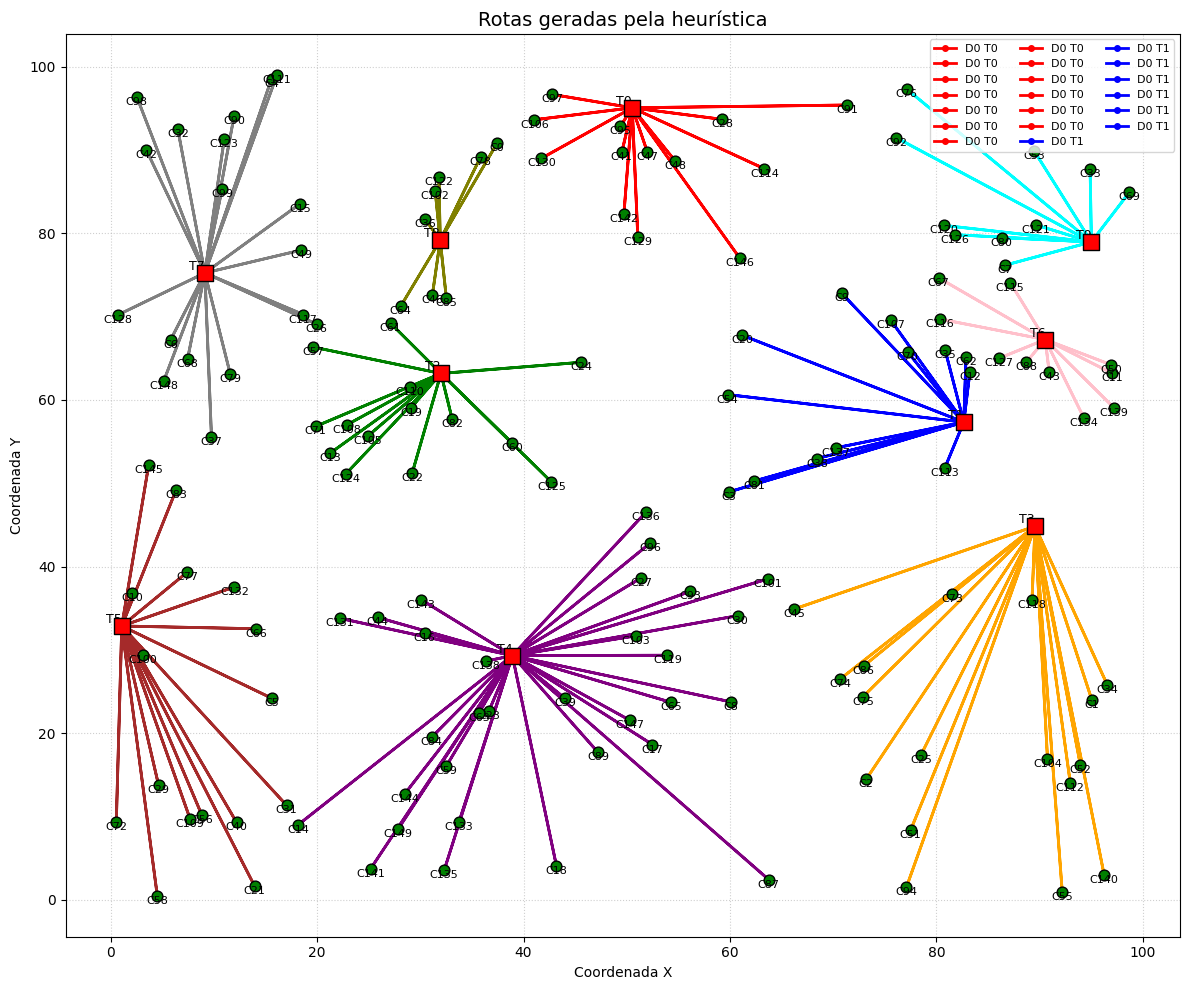

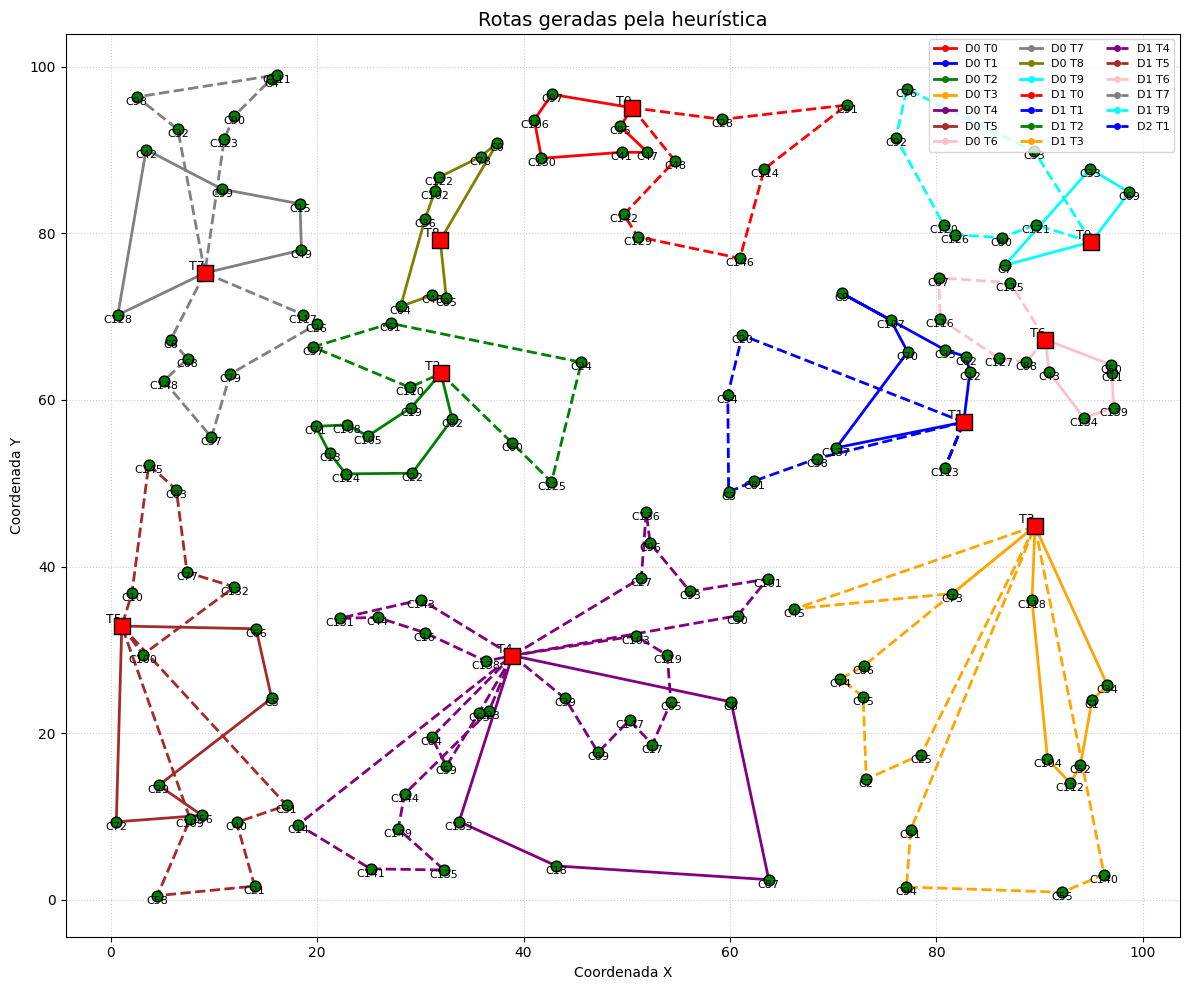

In [50]:
#lê os dados dos arquivos .txt + main
import csv
import matplotlib.pyplot as plt

def ler_arquivos_csv(arquivo_tecnicos, arquivo_clientes):

    dicionario_tecnicos = {}

    dicionario_clientes = {}

    try:
        with open(arquivo_tecnicos, 'r', encoding='utf-8') as file:
            reader = csv.DictReader(file, delimiter=';')

            for row in reader:
                nome_tecnico = row['nome_tecnico']

                dicionario_tecnicos[nome_tecnico] = {
                    'endereco_x': float(row['local_saida_x']),
                    'endereco_y': float(row['local_saida_y'])
                }

    except FileNotFoundError:
        print(f"  Arquivo não encontrado: {arquivo_tecnicos}")
    except KeyError as e:
        print(f"  Coluna não encontrada no arquivo de técnicos: {e}")
    except Exception as e:
        print(f"  Erro ao ler arquivo de técnicos: {e}")

    try:
        with open(arquivo_clientes, 'r', encoding='utf-8') as file:
            reader = csv.DictReader(file, delimiter=';')

            for row in reader:
                nome_cliente = row['nome_cliente']

                dicionario_clientes[nome_cliente] = {
                    'endereco_x': float(row['endereco_x']),
                    'endereco_y': float(row['endereco_y']),
                    'duracao_estimada_minutos': int(row['duracao_estimada_minutos'])
                }

    except FileNotFoundError:
        print(f"  Arquivo não encontrado: {arquivo_clientes}")
    except KeyError as e:
        print(f"  Coluna não encontrada no arquivo de clientes: {e}")
    except Exception as e:
        print(f"  Erro ao ler arquivo de clientes: {e}")

    return dicionario_tecnicos, dicionario_clientes

def plotar_pontos(tecnicos, clientes, arquivo_saida="pontos.png"):
    x_tec = [d['endereco_x'] for d in tecnicos.values()]
    y_tec = [d['endereco_y'] for d in tecnicos.values()]
    x_cli = [d['endereco_x'] for d in clientes.values()]
    y_cli = [d['endereco_y'] for d in clientes.values()]

    plt.figure(figsize=(10, 8))
    plt.scatter(x_tec, y_tec, c='red', label='Técnicos', marker='o')
    plt.scatter(x_cli, y_cli, c='green', label='Clientes', marker='^')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.title('Pontos dos Técnicos e Clientes')
    plt.legend()
    plt.grid(True)
    plt.savefig(arquivo_saida, dpi=150)
    print(f"Gráfico salvo como {arquivo_saida}")

if __name__ == "__main__":
    arquivo_clientes = "clientes.csv"
    arquivo_tecnicos = "tecnicos.csv"

    tecnicos, clientes = ler_arquivos_csv(arquivo_tecnicos, arquivo_clientes)
    print("Leitura dos arquivos concluída")
    #plotar_pontos(tecnicos, clientes)
    #print("Gráfico gerado")
    dij, num_clientes, lista_duracao = matriz_distancia_clientes(clientes)
    aij, num_tecnicos = matriz_distancia_tecnico_cliente(tecnicos,clientes)
    print("Cálculo da distância euclidiana concluída")
    matriz_tempo = juntar_matrizes_tempo(dij, aij)
    print("Matriz de tempo calculada")
    #num_dias= 5
    #solve_MILP(num_tecnicos, num_clientes, num_dias, matriz_tempo, lista_duracao)
    solver = ClarkeWrightSolver(num_tecnicos, num_clientes, matriz_tempo, lista_duracao, 480)
    solucao_inicial = solver._atribuicao_inicial()
    print(f"Distância inicial: {solver._calcular_distancia_total(solucao_inicial):.2f}")
    num_dias=len(solucao_inicial)
    plotar_rotas(solucao_inicial, tecnicos, clientes, num_dias, "rotas_iniciais.png")
    solucao_final = solver.resolver()
    num_dias=len(solucao_final)
    salvar_resultados(solucao_final, tecnicos, clientes, num_dias)
    print(f"Distância final: {solver._calcular_distancia_total(solucao_final):.2f}")
    plotar_rotas(solucao_final, tecnicos, clientes, num_dias, "rotas_clarke_wright.png")
